In [1]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060
Using device    : cuda


In [2]:
"""
SkinLesionClassifier_V5(A) - Gated Fusion with Entropy Regularization
"""

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             classification_report, confusion_matrix,
                             precision_recall_fscore_support)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

# ==============================================================================
# CONFIGURATION
# ==============================================================================



c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()


In [3]:
class Config:
    """Configuration class - modify paths here"""
    # Data paths
    DATA_DIR = r"D:\dataset"
    IMAGE_DIR = os.path.join(DATA_DIR, "images")
    MASK_DIR = os.path.join(DATA_DIR, "mask")
    METADATA_CSV = os.path.join(DATA_DIR, "metadata\HAM10000_metadata.csv")

    # Model paths
    ENCODER_CHECKPOINT = r"D:\PHASE 6\swinunet\swinunet_v4_encoder.pth"
    SAVE_DIR = r"D:\Kimi phase 2 A\output"

    # Training
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    NUM_CLASSES = 7

    # Phase 1 (frozen encoder)
    PHASE1_EPOCHS = 10
    PHASE1_LR = 1e-3

    # Phase 2 (unfrozen encoder)
    PHASE2_EPOCHS = 50
    ENCODER_LR = 1e-5
    HEAD_LR = 5e-5

    # Early stopping
    EARLY_STOPPING_PATIENCE = 10

    # Loss weights
    ENTROPY_REG_WEIGHT = 0.1  # Lambda for entropy regularization

    # Gated fusion
    FUSION_DIM = 512
    GATE_HIDDEN_DIM = 128

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==============================================================================
# REPRODUCIBILITY
# ==============================================================================



In [4]:
def set_seed(seed=42):
    """Set random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ==============================================================================
# METADATA PREPROCESSING
# ==============================================================================



In [5]:
class MetadataPreprocessor:
    """
    Preprocess HAM10000 metadata CSV.
    Encodes categorical variables and normalizes continuous variables.
    """

    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
        self._build_encoders()
        self._compute_stats()

    def _build_encoders(self):
        """Build label encoders for categorical features"""
        # Sex encoding
        self.sex_to_idx = {
            'male': 0,
            'female': 1,
            'unknown': 2
        }

        # Anatomical site encoding
        self.site_to_idx = {
            'abdomen': 0, 'back': 1, 'chest': 2, 'ear': 3,
            'face': 4, 'foot': 5, 'genital': 6, 'hand': 7,
            'leg': 8, 'neck': 9, 'scalp': 10, 'trunk': 11,
            'upper extremity': 12, 'lower extremity': 13,
            'torso': 14, 'unknown': 15
        }

        # Diagnosis (label) encoding
        self.dx_to_idx = {
            'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3,
            'mel': 4, 'nv': 5, 'vasc': 6
        }
        self.idx_to_dx = {v: k for k, v in self.dx_to_idx.items()}

    def _compute_stats(self):
        """Compute normalization statistics for age"""
        ages = self.df['age'].dropna().astype(float)
        self.age_mean = ages.mean()
        self.age_std = ages.std()

    def preprocess(self):
        """Apply all preprocessing steps"""
        df = self.df.copy()

        # Encode labels
        df['label'] = df['dx'].map(self.dx_to_idx)

        # Encode sex
        df['sex'] = df['sex'].str.lower().map(self.sex_to_idx).fillna(2).astype(int)

        # Encode anatomical site
        df['localization'] = df['localization'].str.lower().map(self.site_to_idx).fillna(15).astype(int)

        # Normalize age (handle missing values)
        df['age'] = pd.to_numeric(df['age'], errors='coerce')
        df['age'] = df['age'].fillna(self.age_mean)
        df['age'] = (df['age'] - self.age_mean) / self.age_std

        return df
    
    @property
    def num_sites(self):
        """FIX 3: expose site vocabulary size so MetadataEncoder stays in sync"""
        return len(self.site_to_idx)

    def get_class_weights(self):
        """Compute inverse frequency weights for loss function"""
        counts = self.df['dx'].value_counts()
        total = len(self.df)
        weights = {self.dx_to_idx[cls]: total / (len(counts) * count) 
                   for cls, count in counts.items()}
        return weights


# ==============================================================================
# DATASET
# ==============================================================================





In [6]:
class HAM10000Dataset_Multimodal(Dataset):
    """
    HAM10000 Dataset with image, mask, and metadata.

    Returns:
        dict with keys: 'image', 'mask', 'age', 'sex', 'site', 'label'
    """

    def __init__(self, df, img_dir, mask_dir, transform=None, mode='train', 
                 zero_metadata=False):
        """
        Args:
            df: Preprocessed DataFrame with image_id, label, age, sex, site
            img_dir: Directory containing images
            mask_dir: Directory containing masks
            transform: Albumentations transforms
            mode: 'train', 'val', or 'test'
            zero_metadata: If True, return zeros for metadata (ablation test)
        """
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mode = mode
        self.zero_metadata = zero_metadata

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        label = row['label']

        # Load image
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = np.array(Image.open(img_path).convert("RGB"))

        # Load mask
        mask_candidates = [
            os.path.join(self.mask_dir, f"{img_id}_segmentation.png"),
            os.path.join(self.mask_dir, f"{img_id}_mask.png"),
            os.path.join(self.mask_dir, f"{img_id}.png"),
            os.path.join(self.mask_dir, f"{img_id}.jpg"),
        ]
        mask_path = next((p for p in mask_candidates if os.path.exists(p)), None)
        if mask_path is None:
            # FIX 1: graceful fallback — use all-ones mask (no segmentation available)
            mask = np.ones((image.shape[0], image.shape[1]), dtype=np.float32)
        else:
            mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32) / 255.0

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Ensure mask has channel dimension
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)
        mask = mask.float()

        # Metadata
        if self.zero_metadata:
            # Ablation: zero out metadata to test its impact
            age = torch.tensor([0.0], dtype=torch.float32)
            sex = torch.tensor(2, dtype=torch.long)  # 'unknown'
            site = torch.tensor(15, dtype=torch.long)  # 'unknown'
        else:
            age = torch.tensor([row['age']], dtype=torch.float32)
            sex = torch.tensor(row['sex'], dtype=torch.long)
            site = torch.tensor(row['localization'], dtype=torch.long)

        return {
            'image': image,
            'mask': mask,
            'age': age,
            'sex': sex,
            'site': site,
            'label': torch.tensor(label, dtype=torch.long)
        }


# ==============================================================================
# AUGMENTATIONS
# ==============================================================================



In [7]:
def get_transforms(img_size=224, mode='train'):
    """Get Albumentations transforms"""

    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Rotate(limit=30, p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, approximate=True, p=0.15),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.3),
            A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(8, 32), hole_width_range=(8, 32), p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ], additional_targets={'mask': 'mask'})  # FIX 2: sync spatial transforms to mask
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ], additional_targets={'mask': 'mask'})  # FIX 2: sync spatial transforms to mask


# ==============================================================================
# MODEL COMPONENTS
# ==============================================================================



In [8]:
class MetadataEncoder(nn.Module):
    """
    Encode clinical metadata (age, sex, anatomical site) into feature vector.
    """

    def __init__(self, num_sites=16, sex_embed_dim=8, site_embed_dim=32, out_dim=256):
        super().__init__()
        self.sex_embedding = nn.Embedding(3, sex_embed_dim)           # male/female/unknown
        self.site_embedding = nn.Embedding(num_sites, site_embed_dim)  # FIX 3: dynamic vocab size

        # Input: age(1) + sex_embed(8) + site_embed(32) = 41
        in_dim = 1 + sex_embed_dim + site_embed_dim

        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, age, sex, site):
        """
        Args:
            age: (B, 1) normalized age
            sex: (B,) sex indices
            site: (B,) anatomical site indices
        Returns:
            (B, out_dim) metadata features
        """
        sex_emb = self.sex_embedding(sex)      # (B, 8)
        site_emb = self.site_embedding(site)   # (B, 32)

        x = torch.cat([age, sex_emb, site_emb], dim=-1)  # (B, 41)
        return self.mlp(x)  # (B, 256)




In [9]:
class FeaturePyramidNetwork(nn.Module):
    """
    FPN for multi-scale feature fusion.
    Adapted from your V4 implementation.
    """

    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for in_ch in in_channels_list
        ])

        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for _ in in_channels_list
        ])

    def forward(self, features):
        """
        Args:
            features: List of 4 feature maps from encoder stages
        Returns:
            List of 4 smoothed feature maps at uniform channels
        """
        # Lateral connections (1x1 conv)
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]

        # Top-down pathway
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(
                laterals[i], 
                size=laterals[i-1].shape[2:], 
                mode='nearest'
            )
            laterals[i-1] = laterals[i-1] + upsampled

        # Smooth 3x3 conv
        outputs = [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]
        return outputs




In [10]:
class GatedFusion(nn.Module):
    """
    Gated fusion module with entropy regularization.

    Replaces simple concatenation with learnable gating:
    g = sigmoid(MLP([img_feat, meta_feat]))
    output = g * img_feat + (1-g) * meta_feat (per-dimension gating)

    Also computes entropy regularization loss to prevent collapse.
    """

    def __init__(self, img_dim=1024, meta_dim=256, hidden_dim=128, out_dim=512):
        super().__init__()

        # Project to common dimension
        self.proj_img = nn.Linear(img_dim, out_dim)
        self.proj_meta = nn.Linear(meta_dim, out_dim)

        # Gating network: learns per-sample, per-dimension weights
        self.gate_mlp = nn.Sequential(
            nn.Linear(out_dim * 2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, out_dim),  # Per-dimension gate
            nn.Sigmoid()
        )

        # Final fusion projection
        self.fusion_proj = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

        self.out_dim = out_dim

    def forward(self, img_feat, meta_feat):
        """
        Args:
            img_feat: (B, img_dim) image features from FPN
            meta_feat: (B, meta_dim) metadata features
        Returns:
            fused: (B, out_dim) fused features
            gate_values: (B, out_dim) gating weights (for monitoring)
            entropy_loss: scalar entropy regularization loss
        """
        # Project to common space
        img_proj = self.proj_img(img_feat)    # (B, out_dim)
        meta_proj = self.proj_meta(meta_feat)  # (B, out_dim)

        # Compute gates: per-dimension, per-sample
        concat = torch.cat([img_proj, meta_proj], dim=-1)  # (B, out_dim*2)
        gates = self.gate_mlp(concat)  # (B, out_dim) in [0, 1]

        # Gated fusion: weighted combination
        fused = gates * img_proj + (1 - gates) * meta_proj  # (B, out_dim)

        # Entropy regularization: encourage gates away from 0 or 1
        # H(g) = -g*log(g) - (1-g)*log(1-g), maximized at g=0.5
        # We want HIGH entropy (balanced gating), so minimize negative entropy
        eps = 1e-6
        entropy = -gates * torch.log(gates + eps) - (1 - gates) * torch.log(1 - gates + eps)
        entropy_loss = -entropy.mean()  # Negative because we want to maximize entropy

        return self.fusion_proj(fused), gates, entropy_loss

    def get_modality_contribution(self, gates):
        """
        Compute average contribution of each modality.
        Returns dict with mean gate value (closer to 1 = image dominant)
        """
        return {
            'image_contribution': gates.mean().item(),
            'metadata_contribution': (1 - gates).mean().item(),
            'entropy': (-gates * torch.log(gates + 1e-6) - 
                       (1-gates) * torch.log(1-gates + 1e-6)).mean().item()
        }




In [11]:
class SkinLesionClassifier_V5A(nn.Module):
    """
    V5(A): Gated fusion with entropy regularization.

    Architecture:
    - Swin-B encoder (pretrained on ISIC 2018 segmentation)
    - FPN for multi-scale feature aggregation
    - Mask guidance (element-wise multiplication)
    - Metadata encoder (age, sex, site)
    - Gated fusion (replaces concatenation)
    - Classification head
    """

    def __init__(self, num_classes=7, num_sites=16, pretrained=True, 
                 encoder_checkpoint="swinunet_v4_encoder.pth"):
        super().__init__()

        # Image encoder: Swin Transformer
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        if pretrained and os.path.exists(encoder_checkpoint):
            checkpoint = torch.load(encoder_checkpoint, map_location='cpu')
            self.encoder.load_state_dict(checkpoint, strict=False)
            print(f"Loaded encoder from {encoder_checkpoint}")

        # Feature Pyramid Network
        self.fpn = FeaturePyramidNetwork([128, 256, 512, 1024], 256)

        # Metadata encoder  (FIX 3: pass num_sites so embedding never goes out of range)
        self.metadata_encoder = MetadataEncoder(num_sites=num_sites, out_dim=256)

        # Gated fusion (REPLACES concatenation)
        self.gated_fusion = GatedFusion(
            img_dim=1024,      # 4 x 256 from FPN
            meta_dim=256,
            hidden_dim=128,
            out_dim=512
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def _apply_mask(self, features, mask):
        """Apply segmentation mask to feature maps"""
        masked_features = []
        for feat in features:
            # Resize mask to match feature map size
            mask_resized = F.interpolate(
                mask, size=feat.shape[2:], mode='nearest'
            )
            masked = feat * mask_resized
            masked_features.append(masked)
        return masked_features

    def forward(self, image, mask, age, sex, site):
        """
        Args:
            image: (B, 3, H, W)
            mask: (B, 1, H, W)
            age: (B, 1)
            sex: (B,)
            site: (B,)
        Returns:
            logits: (B, num_classes)
            gate_values: (B, out_dim) for monitoring
            entropy_loss: scalar regularization loss
        """
        # Image encoding
        features = self.encoder(image)  # List of 4 feature maps in NHWC format
        features = [f.permute(0, 3, 1, 2).contiguous() for f in features]

        # Mask guidance
        if mask is not None:
            features = self._apply_mask(features, mask)

        # FPN
        fpn_features = self.fpn(features)

        # Global average pooling and concatenate
        img_feat = torch.cat([
            F.adaptive_avg_pool2d(f, (1, 1)).flatten(1)
            for f in fpn_features
        ], dim=1)  # (B, 1024)

        # Metadata encoding
        meta_feat = self.metadata_encoder(age, sex, site)  # (B, 256)

        # Gated fusion (REPLACES: torch.cat([img_feat, meta_feat], dim=1))
        fused, gates, entropy_loss = self.gated_fusion(img_feat, meta_feat)

        # Classification
        logits = self.classifier(fused)

        return logits, gates, entropy_loss


# ==============================================================================
# TRAINING UTILITIES
# ==============================================================================



In [12]:
def get_class_weights(df):
    """Compute sqrt-inverse frequency weights"""
    counts = df['label'].value_counts().sort_index().values
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(weights)
    return torch.tensor(weights, dtype=torch.float32)




In [13]:
def mixup_data(x, y, alpha=0.4):
    """MixUp augmentation"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam




In [14]:
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """MixUp loss"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ==============================================================================
# TRAINING LOOP
# ==============================================================================



In [15]:
class Trainer:
    """Training manager for V5(A)"""

    def __init__(self, model, config, save_dir):
        self.model = model.to(config.DEVICE)
        self.config = config
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1': [], 'val_f1': []
        }

    def _get_optimizer(self, phase='phase1'):
        """Get optimizer with differential learning rates"""
        if phase == 'phase1':
            # Freeze encoder, train head only
            for param in self.model.encoder.parameters():
                param.requires_grad = False

            trainable_params = [
                {'params': self.model.fpn.parameters()},
                {'params': self.model.metadata_encoder.parameters()},
                {'params': self.model.gated_fusion.parameters()},
                {'params': self.model.classifier.parameters()}
            ]
            return torch.optim.AdamW(trainable_params, lr=self.config.PHASE1_LR, weight_decay=1e-4)

        else:  # phase2
            # Unfreeze encoder with lower LR
            for param in self.model.encoder.parameters():
                param.requires_grad = True

            trainable_params = [
                {'params': self.model.encoder.parameters(), 'lr': self.config.ENCODER_LR},
                {'params': self.model.fpn.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.metadata_encoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.gated_fusion.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.classifier.parameters(), 'lr': self.config.HEAD_LR}
            ]
            return torch.optim.AdamW(trainable_params, weight_decay=1e-4)

    def train_epoch(self, loader, criterion, optimizer, scheduler, use_mixup=True, progress_desc=None):
        """Train for one epoch with a batch progress bar."""
        self.model.train()
        total_loss = 0
        total_correct = 0
        total_seen = 0
        all_preds = []
        all_labels = []

        progress_bar = tqdm(loader, desc=progress_desc or "Training", leave=True)
        for batch_idx, batch in enumerate(progress_bar, start=1):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            ages = batch['age'].to(self.config.DEVICE)
            sexes = batch['sex'].to(self.config.DEVICE)
            sites = batch['site'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)

            optimizer.zero_grad()

            # Forward pass
            logits, gates, entropy_loss = self.model(images, masks, ages, sexes, sites)

            # Classification loss
            cls_loss = criterion(logits, labels)

            # Total loss with entropy regularization
            loss = cls_loss + self.config.ENTROPY_REG_WEIGHT * entropy_loss

            # Backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_seen += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress_bar.set_postfix(
                loss=f"{total_loss / batch_idx:.4f}",
                acc=f"{total_correct / max(total_seen, 1):.4f}"
            )

        if scheduler is not None:
            scheduler.step()

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')

        return total_loss / len(loader), acc, f1

    @torch.no_grad()
    def evaluate(self, loader, criterion):
        """Evaluate on validation/test set"""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        all_probs = []
        gate_stats = []

        for batch in loader:
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            ages = batch['age'].to(self.config.DEVICE)
            sexes = batch['sex'].to(self.config.DEVICE)
            sites = batch['site'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)

            logits, gates, entropy_loss = self.model(images, masks, ages, sexes, sites)

            cls_loss = criterion(logits, labels)
            loss = cls_loss + self.config.ENTROPY_REG_WEIGHT * entropy_loss

            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            # Record gate statistics
            gate_stats.append({
                'image_contrib': gates.mean().item(),
                'meta_contrib': (1 - gates).mean().item(),
                'entropy': (-gates * torch.log(gates + 1e-6) - 
                           (1-gates) * torch.log(1-gates + 1e-6)).mean().item()
            })

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')

        # Macro AUC
        try:
            auc = roc_auc_score(
                np.eye(self.config.NUM_CLASSES)[all_labels], 
                np.array(all_probs), 
                average='macro', multi_class='ovr'
            )
        except:
            auc = 0.0

        # Average gate statistics
        avg_gate_stats = {
            k: np.mean([g[k] for g in gate_stats])
            for k in gate_stats[0].keys()
        }

        return total_loss / len(loader), acc, f1, auc, avg_gate_stats

    def _phase_checkpoint_path(self, phase):
        return os.path.join(self.save_dir, f'{phase}_checkpoint.pth')

    def _save_phase_checkpoint(self, phase, epoch, optimizer, scheduler, best_val_f1,
                               patience_counter, gate_stats=None):
        """Save the latest phase checkpoint so training can resume after an interruption."""
        checkpoint = {
            'phase': phase,
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'history': self.history,
            'best_val_f1': best_val_f1,
            'patience_counter': patience_counter,
            'gate_stats': gate_stats,
        }
        torch.save(checkpoint, self._phase_checkpoint_path(phase))

    def _load_phase_checkpoint(self, phase, optimizer, scheduler):
        """Load a phase checkpoint and return the next epoch to run."""
        checkpoint_path = self._phase_checkpoint_path(phase)
        if not os.path.exists(checkpoint_path):
            return 0, -float('inf'), 0

        checkpoint = torch.load(checkpoint_path, map_location=self.config.DEVICE)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if scheduler is not None and checkpoint.get('scheduler_state_dict') is not None:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        if checkpoint.get('history') is not None:
            self.history = checkpoint['history']

        start_epoch = checkpoint['epoch'] + 1
        best_val_f1 = checkpoint.get('best_val_f1', 0.0)
        patience_counter = checkpoint.get('patience_counter', 0)
        print(f"Resuming {phase} from epoch {start_epoch + 1}")
        return start_epoch, best_val_f1, patience_counter

    def train_phase(self, phase, train_loader, val_loader, class_weights, resume=True):
        """Train one phase. Re-run the cell to resume from the latest saved epoch."""
        if phase not in ('phase1', 'phase2'):
            raise ValueError("phase must be 'phase1' or 'phase2'")

        criterion = nn.CrossEntropyLoss(weight=class_weights.to(self.config.DEVICE))
        total_epochs = self.config.PHASE1_EPOCHS if phase == 'phase1' else self.config.PHASE2_EPOCHS
        title = (
            'PHASE 1: Training with frozen encoder'
            if phase == 'phase1'
            else 'PHASE 2: Fine-tuning with unfrozen encoder'
        )

        print("\n" + "="*60)
        print(title)
        print("="*60)

        optimizer = self._get_optimizer(phase)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2
        )

        start_epoch = 0
        best_val_f1 = -float('inf')
        patience_counter = 0
        if resume:
            start_epoch, best_val_f1, patience_counter = self._load_phase_checkpoint(
                phase, optimizer, scheduler
            )
            if phase == 'phase2' and start_epoch == 0 and not os.path.exists(self._phase_checkpoint_path('phase2')):
                phase1_checkpoint = self._phase_checkpoint_path('phase1')
                if os.path.exists(phase1_checkpoint):
                    checkpoint = torch.load(phase1_checkpoint, map_location=self.config.DEVICE)
                    self.model.load_state_dict(checkpoint['model_state_dict'])
                    print("Loaded completed Phase 1 checkpoint before starting Phase 2")

        if start_epoch >= total_epochs:
            print(f"{phase} is already complete ({total_epochs}/{total_epochs} epochs).")
            return best_val_f1

        for epoch in range(start_epoch, total_epochs):
            phase_label = 'Phase 1' if phase == 'phase1' else 'Phase 2'
            train_loss, train_acc, train_f1 = self.train_epoch(
                train_loader, criterion, optimizer, scheduler,
                progress_desc=f"{phase_label} Epoch {epoch+1}/{total_epochs}"
            )
            val_loss, val_acc, val_f1, val_auc, gate_stats = self.evaluate(
                val_loader, criterion
            )

            print(f"Epoch {epoch+1}/{total_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f} | "
                  f"Gates: img={gate_stats['image_contrib']:.3f} meta={gate_stats['meta_contrib']:.3f}")

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['train_f1'].append(train_f1)
            self.history['val_f1'].append(val_f1)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                best_name = 'phase1_best_model.pth' if phase == 'phase1' else 'best_model.pth'
                torch.save({
                    'phase': phase,
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'history': self.history,
                    'val_f1': val_f1,
                    'gate_stats': gate_stats
                }, os.path.join(self.save_dir, best_name))
                print(f"  -> Saved best {phase} model (val F1: {val_f1:.4f})")
            else:
                patience_counter += 1

            self._save_phase_checkpoint(
                phase, epoch, optimizer, scheduler, best_val_f1, patience_counter, gate_stats
            )
            print(f"  -> Saved latest {phase} checkpoint")

            if phase == 'phase2' and patience_counter >= self.config.EARLY_STOPPING_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"\nBest validation F1 for {phase}: {best_val_f1:.4f}")
        return best_val_f1

    def fit(self, train_loader, val_loader, class_weights):
        """Full training loop. Kept for script-style runs; notebook cells call train_phase directly."""
        self.train_phase('phase1', train_loader, val_loader, class_weights)
        self.train_phase('phase2', train_loader, val_loader, class_weights)

    def plot_history(self):
        """Plot training curves"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(self.history['train_loss'], label='Train')
        axes[0].plot(self.history['val_loss'], label='Val')
        axes[0].set_title('Loss')
        axes[0].legend()

        axes[1].plot(self.history['train_acc'], label='Train')
        axes[1].plot(self.history['val_acc'], label='Val')
        axes[1].set_title('Accuracy')
        axes[1].legend()

        axes[2].plot(self.history['train_f1'], label='Train')
        axes[2].plot(self.history['val_f1'], label='Val')
        axes[2].set_title('Macro F1')
        axes[2].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, 'training_curves.png'))
        plt.show()


# ==============================================================================
# EVALUATION & TESTING
# ==============================================================================



In [16]:
def evaluate_model(model, test_loader, config, save_dir):
    """Comprehensive evaluation on test set"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            masks = batch['mask'].to(config.DEVICE)
            ages = batch['age'].to(config.DEVICE)
            sexes = batch['sex'].to(config.DEVICE)
            sites = batch['site'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)

            logits, gates, _ = model(images, masks, ages, sexes, sites)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    try:
        auc_macro = roc_auc_score(
            np.eye(config.NUM_CLASSES)[all_labels],
            np.array(all_probs),
            average='macro', multi_class='ovr'
        )
    except:
        auc_macro = 0.0

    # Classification report
    report = classification_report(
        all_labels, all_preds,
        target_names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
        output_dict=True
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
                yticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'])
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
    plt.show()

    # Print results
    print("\n" + "="*60)
    print("TEST RESULTS")
    print("="*60)
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"Macro AUC: {auc_macro:.4f}")
    print("\nPer-class metrics:")
    for cls in ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']:
        print(f"  {cls:6s}: Precision={report[cls]['precision']:.4f}, "
              f"Recall={report[cls]['recall']:.4f}, F1={report[cls]['f1-score']:.4f}")

    return {
        'accuracy': acc,
        'macro_f1': f1_macro,
        'weighted_f1': f1_weighted,
        'macro_auc': auc_macro,
        'per_class': report,
        'confusion_matrix': cm
    }




In [17]:
def test_with_zero_metadata(model, test_loader, config):
    """Ablation: Test with metadata zeroed out"""
    print("\n" + "="*60)
    print("ABLATION: Zero Metadata Test")
    print("="*60)

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            masks = batch['mask'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)

            # Zero out metadata
            batch_size = images.size(0)
            ages = torch.zeros(batch_size, 1).to(config.DEVICE)
            sexes = torch.full((batch_size,), 2, dtype=torch.long).to(config.DEVICE)  # unknown
            sites = torch.full((batch_size,), 15, dtype=torch.long).to(config.DEVICE)  # unknown

            logits, _, _ = model(images, masks, ages, sexes, sites)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"Zero-metadata Accuracy: {acc:.4f}")
    print(f"Zero-metadata Macro F1: {f1:.4f}")
    print(f"\nComparison with full metadata:")
    print(f"  If zero-metadata performs BETTER, metadata is hurting the model.")
    print(f"  If zero-metadata performs WORSE, metadata is helping.")

    return {'accuracy': acc, 'macro_f1': f1}


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================



In [18]:
# Notebook setup: run this once before Phase 1 / Phase 2 training cells
config = Config()
set_seed(config.SEED)

print("="*60)
print("SkinLesionClassifier V5(A) - Gated Fusion with Entropy Regularization")
print("="*60)
print(f"Device: {config.DEVICE}")
print(f"Entropy reg weight: {config.ENTROPY_REG_WEIGHT}")
print(f"Fusion dim: {config.FUSION_DIM}")

print("\n[1/5] Loading metadata...")
preprocessor = MetadataPreprocessor(config.METADATA_CSV)
df = preprocessor.preprocess()
class_weights = get_class_weights(df)
print(f"Dataset size: {len(df)}")
print(f"Class distribution: {df['dx'].value_counts().to_dict()}")

print("\n[2/5] Splitting dataset...")
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=config.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=config.SEED
)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

print("\n[3/5] Creating datasets...")
train_dataset = HAM10000Dataset_Multimodal(
    train_df, config.IMAGE_DIR, config.MASK_DIR,
    transform=get_transforms(config.IMG_SIZE, 'train'),
    mode='train', zero_metadata=False
)
val_dataset = HAM10000Dataset_Multimodal(
    val_df, config.IMAGE_DIR, config.MASK_DIR,
    transform=get_transforms(config.IMG_SIZE, 'val'),
    mode='val', zero_metadata=False
)
test_dataset = HAM10000Dataset_Multimodal(
    test_df, config.IMAGE_DIR, config.MASK_DIR,
    transform=get_transforms(config.IMG_SIZE, 'val'),
    mode='test', zero_metadata=False
)

print("\n[4/5] Creating data loaders...")
sampler = WeightedRandomSampler(
    weights=[class_weights[label] for label in train_df['label'].values],
    num_samples=len(train_df),
    replacement=True
)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, sampler=sampler,
    num_workers=config.NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
    num_workers=config.NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
    num_workers=config.NUM_WORKERS, pin_memory=True
)

print("\n[5/5] Initializing model...")
model = SkinLesionClassifier_V5A(
    num_classes=config.NUM_CLASSES,
    num_sites=preprocessor.num_sites,
    pretrained=True,
    encoder_checkpoint=config.ENCODER_CHECKPOINT
)

trainer = Trainer(model, config, config.SAVE_DIR)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Checkpoints will be saved to: {config.SAVE_DIR}")


SkinLesionClassifier V5(A) - Gated Fusion with Entropy Regularization
Device: cuda
Entropy reg weight: 0.1
Fusion dim: 512

[1/5] Loading metadata...
Dataset size: 10015
Class distribution: {'nv': 6705, 'mel': 1113, 'bkl': 1099, 'bcc': 514, 'akiec': 327, 'vasc': 142, 'df': 115}

[2/5] Splitting dataset...
Train: 7010 | Val: 1502 | Test: 1503

[3/5] Creating datasets...

[4/5] Creating data loaders...

[5/5] Initializing model...


C:\Users\user\AppData\Local\Temp\ipykernel_17288\1230126926.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(encoder_checkpoint, map_location='cp

Loaded encoder from D:\PHASE 6\swinunet\swinunet_v4_encoder.pth
Total parameters: 90,982,231
Trainable parameters: 90,982,231
Checkpoints will be saved to: D:\Kimi phase 2 A\output


In [19]:
# Phase 1 training cell
# Re-run this cell to resume from phase1_checkpoint.pth after an interruption.
phase1_best_val_f1 = trainer.train_phase(
    'phase1', train_loader, val_loader, class_weights, resume=True
)



PHASE 1: Training with frozen encoder


Phase 1 Epoch 1/10:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 1.5847 Acc: 0.3345 F1: 0.2812 | Val Loss: 1.3325 Acc: 0.5320 F1: 0.2510 AUC: 0.8507 | Gates: img=0.458 meta=0.542
  -> Saved best phase1 model (val F1: 0.2510)
  -> Saved latest phase1 checkpoint


Phase 1 Epoch 2/10:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 2/10 | Train Loss: 1.3727 Acc: 0.4397 F1: 0.3935 | Val Loss: 1.2914 Acc: 0.5832 F1: 0.3915 AUC: 0.8632 | Gates: img=0.365 meta=0.635
  -> Saved best phase1 model (val F1: 0.3915)
  -> Saved latest phase1 checkpoint


...

Epoch 8/10 | Train Loss: 0.9714 Acc: 0.5837 F1: 0.5569 | Val Loss: 0.9488 Acc: 0.6471 F1: 0.4606 AUC: 0.9168 | Gates: img=0.451 meta=0.549
  -> Saved best phase1 model (val F1: 0.4606)
  -> Saved latest phase1 checkpoint


Phase 1 Epoch 9/10:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.9392 Acc: 0.6053 F1: 0.5772 | Val Loss: 0.9227 Acc: 0.6491 F1: 0.4780 AUC: 0.9193 | Gates: img=0.442 meta=0.558
  -> Saved best phase1 model (val F1: 0.4780)
  -> Saved latest phase1 checkpoint


Phase 1 Epoch 10/10:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.8839 Acc: 0.6074 F1: 0.5850 | Val Loss: 0.9203 Acc: 0.6345 F1: 0.4691 AUC: 0.9177 | Gates: img=0.449 meta=0.551
  -> Saved latest phase1 checkpoint

Best validation F1 for phase1: 0.4780


In [19]:
# Phase 2 training cell
# Re-run this cell to resume from phase2_checkpoint.pth after an interruption.
phase2_best_val_f1 = trainer.train_phase(
    'phase2', train_loader, val_loader, class_weights, resume=True
)



PHASE 2: Fine-tuning with unfrozen encoder


C:\Users\user\AppData\Local\Temp\ipykernel_17288\1068417666.py:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=self.

Resuming phase2 from epoch 19


Phase 2 Epoch 19/50:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 19/50 | Train Loss: 0.7588 Acc: 0.6592 F1: 0.6530 | Val Loss: 0.9187 Acc: 0.6325 F1: 0.4970 AUC: 0.9216 | Gates: img=0.464 meta=0.536
  -> Saved latest phase2 checkpoint


...

Epoch 35/50 | Train Loss: 0.7352 Acc: 0.6641 F1: 0.6611 | Val Loss: 0.8434 Acc: 0.6565 F1: 0.5184 AUC: 0.9305 | Gates: img=0.467 meta=0.533
  -> Saved latest phase2 checkpoint


Phase 2 Epoch 36/50:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 36/50 | Train Loss: 0.7074 Acc: 0.6787 F1: 0.6753 | Val Loss: 0.8307 Acc: 0.6744 F1: 0.5266 AUC: 0.9326 | Gates: img=0.477 meta=0.523
  -> Saved latest phase2 checkpoint


Phase 2 Epoch 37/50:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 37/50 | Train Loss: 0.6780 Acc: 0.6743 F1: 0.6768 | Val Loss: 0.8521 Acc: 0.6625 F1: 0.5246 AUC: 0.9285 | Gates: img=0.476 meta=0.524
  -> Saved latest phase2 checkpoint

Early stopping at epoch 37

Best validation F1 for phase2: 0.5354


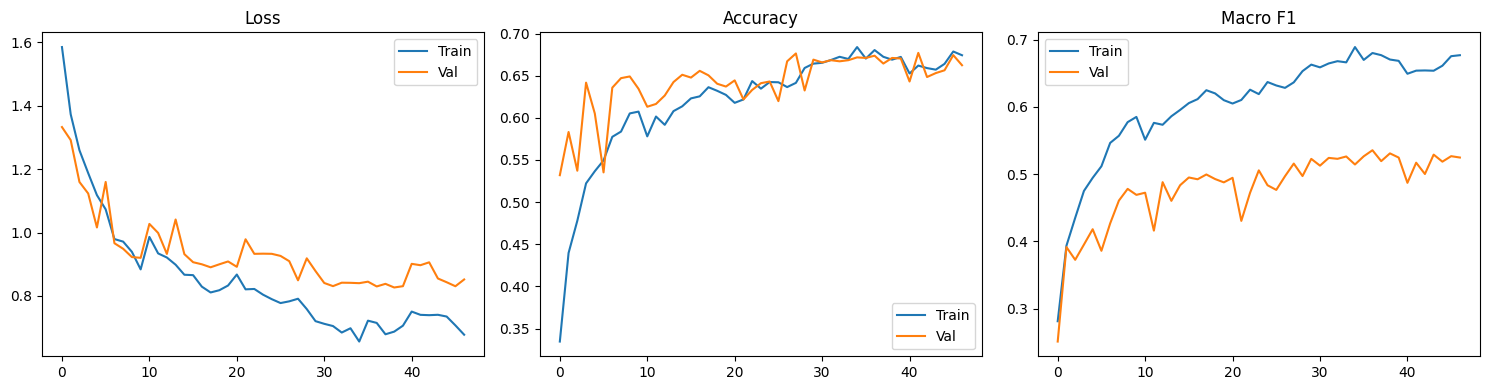

In [20]:
# Plot training curves after running Phase 1 and/or Phase 2
trainer.plot_history()



FINAL EVALUATION


C:\Users\user\AppData\Local\Temp\ipykernel_17288\1854597667.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(config.SAVE_DIR, 'best_m

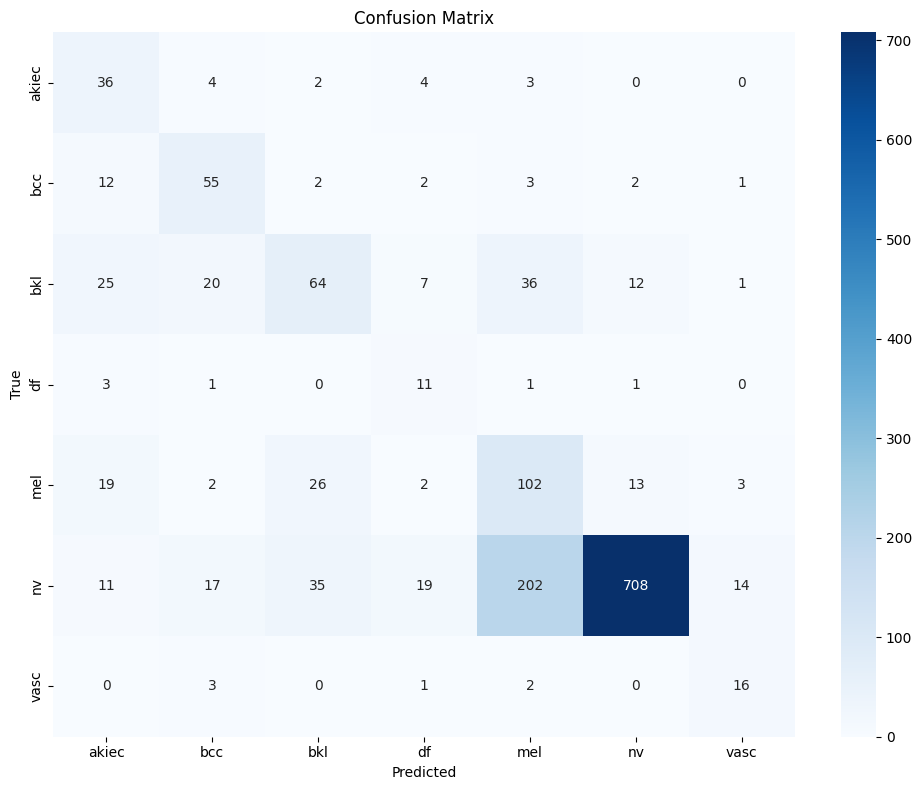


TEST RESULTS
Accuracy: 0.6600
Macro F1: 0.5190
Weighted F1: 0.6946
Macro AUC: 0.9219

Per-class metrics:
  akiec : Precision=0.3396, Recall=0.7347, F1=0.4645
  bcc   : Precision=0.5392, Recall=0.7143, F1=0.6145
  bkl   : Precision=0.4961, Recall=0.3879, F1=0.4354
  df    : Precision=0.2391, Recall=0.6471, F1=0.3492
  mel   : Precision=0.2923, Recall=0.6108, F1=0.3953
  nv    : Precision=0.9620, Recall=0.7038, F1=0.8129
  vasc  : Precision=0.4571, Recall=0.7273, F1=0.5614

ABLATION: Zero Metadata Test
Zero-metadata Accuracy: 0.6600
Zero-metadata Macro F1: 0.3707

Comparison with full metadata:
  If zero-metadata performs BETTER, metadata is hurting the model.
  If zero-metadata performs WORSE, metadata is helping.

SUMMARY
V5(A) with gated fusion:
  Test Accuracy: 0.6600
  Test Macro F1: 0.5190
  Test Macro AUC: 0.9219

V5(A) with ZERO metadata:
  Test Accuracy: 0.6600
  Test Macro F1: 0.3707

Target (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733

NEEDS IMPROVEMENT: Did not beat V4-

In [21]:
# Final evaluation
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

checkpoint = torch.load(os.path.join(config.SAVE_DIR, 'best_model.pth'), map_location=config.DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])

results_full = evaluate_model(model, test_loader, config, config.SAVE_DIR)
results_zero = test_with_zero_metadata(model, test_loader, config)

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"V5(A) with gated fusion:")
print(f"  Test Accuracy: {results_full['accuracy']:.4f}")
print(f"  Test Macro F1: {results_full['macro_f1']:.4f}")
print(f"  Test Macro AUC: {results_full['macro_auc']:.4f}")
print(f"\nV5(A) with ZERO metadata:")
print(f"  Test Accuracy: {results_zero['accuracy']:.4f}")
print(f"  Test Macro F1: {results_zero['macro_f1']:.4f}")
print(f"\nTarget (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733")

if results_full['accuracy'] > 0.835:
    print("\nSUCCESS: Beat V4-C baseline!")
else:
    print("\nNEEDS IMPROVEMENT: Did not beat V4-C baseline.")
    print("   Consider: increasing entropy weight, tuning gate architecture,")
    print("   or adding morphology branch (Phase 3).")

print(f"\nResults saved to: {config.SAVE_DIR}")
